In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import collections

In [2]:
try:
    data = pd.read_csv('spam.csv', encoding='utf-8')
except UnicodeDecodeError:
    # Fall back to latin-1 if UTF-8 fails
    data = pd.read_csv('spam.csv', encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True, axis=1)


In [4]:
data.rename(columns={'v1':"Spam",'v2':"Message"},inplace=True)
data

,Spam,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
data['Spam']=data['Spam'].map({"ham":False,'spam':True})

In [6]:
spam=data[data['Spam']==True]
not_spam=data[data['Spam']==False]
spam

,Spam,Message
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
5,True,FreeMsg Hey there darling it's been 3 week's n...
8,True,WINNER!! As a valued network customer you have...
9,True,Had your mobile 11 months or more? U R entitle...
11,True,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5537,True,Want explicit SEX in 30 secs? Ring 02073162414...
5540,True,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,True,Had your contract mobile 11 Mnths? Latest Moto...
5566,True,REMINDER FROM O2: To get 2.50 pounds free call...


In [7]:
not_spam

,Spam,Message
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."
6,False,Even my brother is not like to speak with me. ...
...,...,...
5565,False,Huh y lei...
5568,False,Will Ì_ b going to esplanade fr home?
5569,False,"Pity, * was in mood for that. So...any other s..."
5570,False,The guy did some bitching but I acted like i'd...


In [8]:
##word counter
def countWord(data):
    count=collections.OrderedDict()
    for msg in data:
        for word in msg.split(' '):
            if word in count:
                count[word]+=1
            else: 
                count[word]=1
    return count

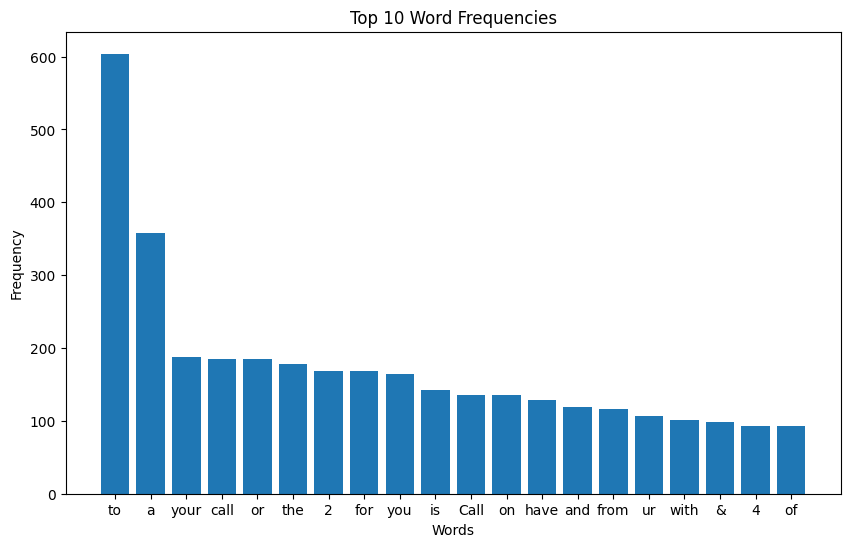

In [9]:
word_counts=countWord(spam['Message'])
sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
top_words = sorted_word_counts[:20]

words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Word Frequencies")
plt.show()

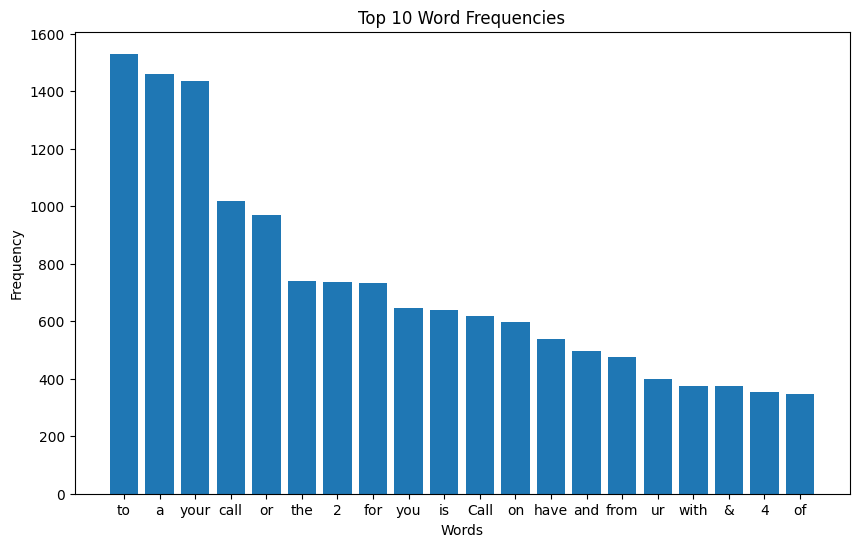

In [10]:
counts=countWord(not_spam['Message'])
sorted_word_=sorted(counts.items(),key=lambda x:x[1],reverse=True)
top=sorted_word_[:20]
word,counts=zip(*top)
plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Word Frequencies")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(data['Message'],data['Spam'])
ytest

285     False
5118    False
1308    False
2003    False
4275    False
        ...  
1211    False
818     False
3082    False
2263     True
4533    False
Name: Spam, Length: 1393, dtype: bool

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


In [13]:
from sklearn.pipeline import Pipeline
pln=Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])

In [14]:
pln.fit(xtrain,ytrain)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [15]:
emails=[
    'Sounds great! Are you home now?',
    'Will u meet ur dream partner soon? Is ur career off 2 a flyng start? 2 find out free, txt HORO followed by ur star sign, e. g. HORO ARIES'
]

In [16]:
pln.predict(emails)

array([False,  True])

In [17]:
predict=pln.predict(xtest)

In [20]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(predict,ytest)
cf

array([[1209,   20],
       [   5,  159]], dtype=int64)

In [21]:
pln.score(xtest,ytest)

0.9820531227566404